<a href="https://colab.research.google.com/github/hjiwoong/DL/blob/main/day12_practice1_EasyOCR_%EA%B8%B0%EC%B4%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# EasyOCR 기초 - 사진에서 글자를 읽는다
# OCR(Optical Character Recognition 광학 문자 인식) = 글자 영역 찾기(감지) + 읽기(인식)
# EasyOCR 결과 구조 - 박스, 내용, 신뢰도

In [2]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972.1/972.1 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 16.9 MB/s eta 0:00:00


In [4]:
import easyocr
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [6]:
# 셀 1. Reader 생성
reader = easyocr.Reader(["ko", "en"], gpu=False, verbose=False) # OCR 엔진 객체 생성 (언어를 정하면 모델을 메모리에 로드)

In [7]:
!apt-get -qq install -y fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib      # 폰트 캐시 비우기

In [10]:
# 셀 2. OCR 시각화 도구 준비 - 원본 이미지 vs 판독 결과 이미지
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


def load_font(size=48):
    return ImageFont.truetype(font_path, size)

def draw_ocr_boxes(image_path, results, box_color="red", text_color="blue"):
  img = Image.open(image_path).convert("RGB")
  d = ImageDraw.Draw(img)
  font = load_font(48)

  for box, text, conf in results: # box = [[x1, y1], [x2, y2], [x3, y3], [x4, y4]] 네 꼭짓점 좌표 (기울어진 글자도 표현 가능)
    points = [tuple(p) for p in box]
    d.line(points + [points[0]], fill=box_color, width=3) # 네 변을 선으로 순서대로 잇고, 마지막에 첫 점으로 돌아와 닫힌 사각형 완성
    label = f"{text} ({conf:.2f})"
    label_pos = (points[0][0], max(points[0][1] - 26, 0))
    d.text(label_pos, label, fill=text_color, font=font)
  return img

def show_original_and_result(image_path, results):
  result_img = draw_ocr_boxes(image_path, results)
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))
  axes[0].imshow(plt.imread(image_path))
  axes[0].set_title("원본 이미지")
  axes[0].axis("off")

  axes[1].imshow(result_img)
  axes[1].set_title("OCR 판독 결과")
  axes[1].axis("off")
  plt.show()

[결과 구조] 항목 = (박스, 텍스트, 신뢰도) - 신뢰도 0.3 이상만
텍스트: 'ABC 1234'
신뢰도: 0.59
박스(네 꼭짓점): [[611, 443], [932, 443], [932, 520], [611, 520]]


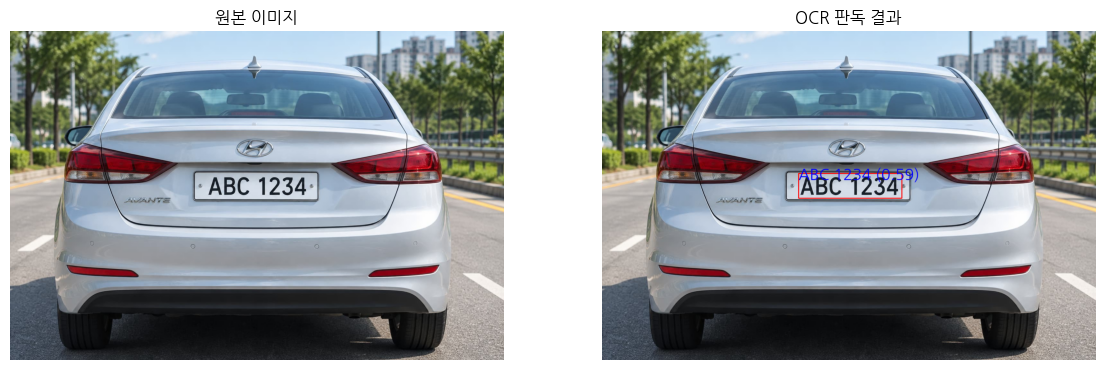

In [13]:
# 셀 3. readtext
results = reader.readtext("sample1.jpg") # 글자를 읽어 결과 리스트 반환 [박스, 텍스트, 신뢰도]

CONF_MIN = 0.3 # 필요없는 쓰레기 글자 제외
results = [(box, text, conf) for box, text, conf in results if conf >= CONF_MIN]
print("[결과 구조] 항목 = (박스, 텍스트, 신뢰도) - 신뢰도 %.1f 이상만" %CONF_MIN)
for box, text, conf in results:
  print(f"텍스트: {text!r}") # !r = 따옴표까지 표시
  print(f"신뢰도: {conf:.2f}")
  print(f"박스(네 꼭짓점): {[[round(v) for v in p] for p in box]}")
show_original_and_result("sample1.jpg", results)

[sample2a.jpg] 글자 덩어리 1개 케이스
덩어리: 'HELLO' (conf 0.77)


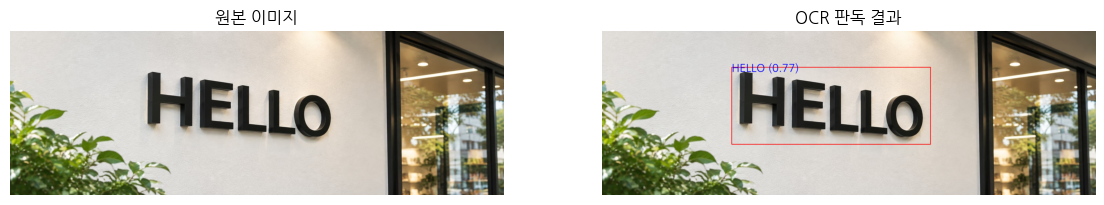


[sample2.jpg] 글자(LED) 덩어리 2개 케이스
덩어리: 'HEa' (conf 0.02)
덩어리: 'WOaD' (conf 0.06)
덩어리: '99' (conf 0.90)


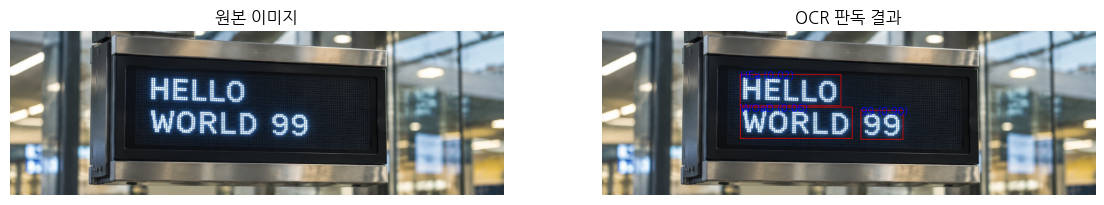


[sample3.jpg] 글자 덩어리 2개 케이스
덩어리: 'HELLO' (conf 0.88)
덩어리: 'WORLD 99' (conf 0.71)


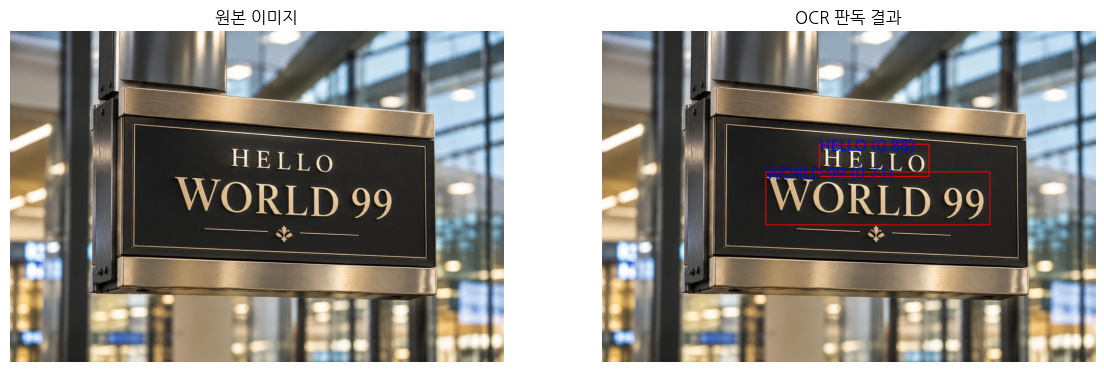

In [14]:
# 셀 4. OCR의 2단계 - 감지와 인식은 별개 모델
print("[sample2a.jpg] 글자 덩어리 1개 케이스")
results_2a = reader.readtext("sample2a.jpg")
for box, text, conf in results_2a:
  print(f"덩어리: {text!r} (conf {conf:.2f})")
show_original_and_result("sample2a.jpg", results_2a)

print("\n[sample2.jpg] 글자(LED) 덩어리 2개 케이스") # 도트 매트릭스(LED 전광판) 폰트라서 EasyOCR이 특히 약한 케이스
results_2 = reader.readtext("sample2.jpg")
for box, text, conf in results_2:
  print(f"덩어리: {text!r} (conf {conf:.2f})")
show_original_and_result("sample2.jpg", results_2)

print("\n[sample3.jpg] 글자 덩어리 2개 케이스")
results_3 = reader.readtext("sample3.jpg")
for box, text, conf in results_3:
  print(f"덩어리: {text!r} (conf {conf:.2f})")
show_original_and_result("sample3.jpg", results_3)

[allowlist] 숫자, 대문자만 허용:
'ABC1234'(conf 0.66)
'AANZE'(conf 0.09)


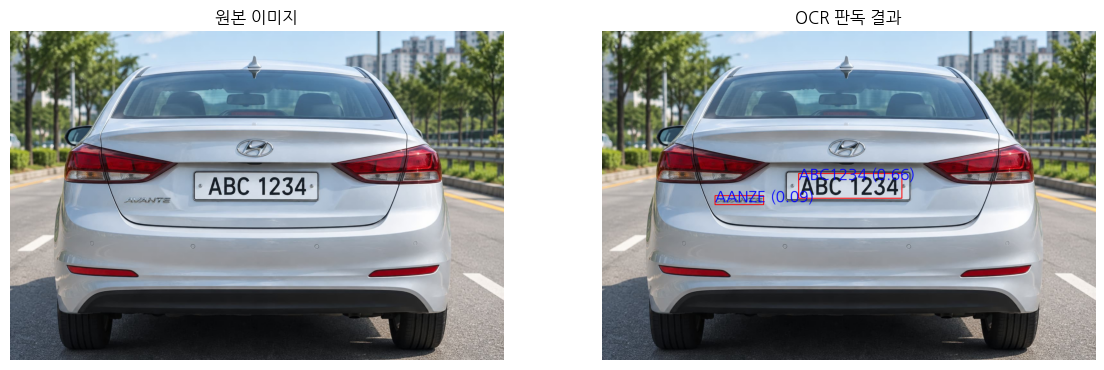

[detail=0]: ['HELLO', 'WORLD 99']
[paragraph]: ['HELLO', 'WORLD 99']


In [15]:
# 셀 5. 실전 옵션 3가지

# 1. allowlist - 나올 수 있는 글자만 허용 (오인식 대폭 감소)
print("[allowlist] 숫자, 대문자만 허용:")
allow_results = reader.readtext("sample1.jpg", allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
for box, text, conf in allow_results:
  print(f"{text!r}(conf {conf:.2f})")
show_original_and_result("sample1.jpg", allow_results)

# 2. detail = 0 - 텍스트만 간단히
print("[detail=0]:", reader.readtext("sample3.jpg", detail=0))

# 3. paragraph=True - 가까운 덩어리를 문단으로 합침
print("[paragraph]:", reader.readtext("sample3.jpg", detail=0, paragraph=True))